# **Optimizing One-Way partial AUC on Imbalanced CIFAR10 Dataset (SOPA)**

**Author**: Dixian Zhu, Zhuoning Yuan, Gang Li, Tianbao Yang
**Version**: 1.4.0 

**Introduction**

In this tutorial, we will learn how to quickly train a ResNet18 model by optimizing **one way partial AUC (OPAUC)** score using our novel `pAUC_CVaR_Loss` and `SOPA` optimizer 
 [[Ref]](https://proceedings.mlr.press/v162/zhu22g.html) method on an binary image classification task on Cifar10. After completion of this tutorial, you should be able to use LibAUC to train your own models on your own datasets.

**Reference**:
   
If you find this tutorial helpful in your work, please cite our [library paper](https://arxiv.org/abs/2306.03065) and the following papers:
```
@inproceedings{zhu2022auc,
              title={When auc meets dro: Optimizing partial auc for deep learning with non-convex convergence guarantee},
              author={Zhu, Dixian and Li, Gang and Wang, Bokun and Wu, Xiaodong and Yang, Tianbao},
              booktitle={International Conference on Machine Learning},
              pages={27548--27573},
              year={2022},
              organization={PMLR}
            }

```




# **Installing LibAUC**

Let’s start with installing our library here. In this tutorial, we will use the lastest version for LibAUC by using ``pip install -U``.

In [ ]:
!pip install -U libauc

# **Importing LibAUC**

In [1]:
from libauc.models import resnet18
from libauc.datasets import CIFAR10
from libauc.utils import ImbalancedDataGenerator
from libauc.losses import pAUC_CVaR_Loss
from libauc.optimizers import SOPA
from libauc.utils import ImbalancedDataGenerator
from libauc.sampler import DualSampler  # data resampling (for binary class)
from libauc.metrics import pauc_roc_score

import torch
from PIL import Image
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import Dataset

# **Reproducibility**

These functions limit the number of sources of randomness behaviors, such as model intialization, data shuffling, etcs. However, completely reproducible results are not guaranteed across PyTorch releases [[Ref]](https://pytorch.org/docs/stable/notes/randomness.html#:~:text=Completely%20reproducible%20results%20are%20not,even%20when%20using%20identical%20seeds.).

In [3]:
def set_all_seeds(SEED):
    # REPRODUCIBILITY
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_all_seeds(2023)

# **Image Dataset**

Now we define the data input pipeline such as data augmentations. In this tutorials, we use ``RandomCrop``, ``RandomHorizontalFlip``. The ``pos_index_map`` helps map global index to local index for reducing memory cost in loss function since we only need to track the indices for positive samples.


In [4]:
class ImageDataset(Dataset):
  def __init__(self, images, targets, image_size=32, crop_size=30, mode='train'):
     self.images = images.astype(np.uint8)
     self.targets = targets
     self.mode = mode
     self.transform_train = transforms.Compose([
                            transforms.ToTensor(),
                            transforms.RandomCrop((crop_size, crop_size), padding=None),
                            transforms.RandomHorizontalFlip(),
                            transforms.Resize((image_size, image_size)),
                            ])
     self.transform_test = transforms.Compose([
                           transforms.ToTensor(),
                           transforms.Resize((image_size, image_size)),
                            ])

     # for loss function
     self.pos_indices = np.flatnonzero(targets==1)
     self.pos_index_map = {}
     for i, idx in enumerate(self.pos_indices):
         self.pos_index_map[idx] = i

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      image = self.images[idx]
      target = self.targets[idx]
      image = Image.fromarray(image.astype('uint8'))
      if self.mode == 'train':
          idx = self.pos_index_map[idx] if idx in self.pos_indices else -1
          image = self.transform_train(image)
      else:
          image = self.transform_test(image)
      return image, target, idx

# **HyperParameters**

In [5]:
# HyperParameters
batch_size = 64
total_epochs = 60
weight_decay = 2e-4 # regularization weight decay
lr = 1e-3  # learning rate
eta = 1.0 # learning rate for control negative samples weights
decay_epochs = [30, 45]
decay_factor = 10
beta = 0.1 # upper bound for FPR
load_pretrain = False


# **Loading datasets**

In [6]:
# load data as numpy arrays
train_data, train_targets = CIFAR10(root='./data', train=True).as_array()
test_data, test_targets  = CIFAR10(root='./data', train=False).as_array()

# generate imbalanced data
imratio = 0.2
generator = ImbalancedDataGenerator(shuffle=True, verbose=True, random_seed=2023)
(train_images, train_labels) = generator.transform(train_data, train_targets, imratio=imratio)
(test_images, test_labels) = generator.transform(test_data, test_targets, imratio=imratio)

# data augmentations
trainDataset = ImageDataset(train_images, train_labels)
testDataset = ImageDataset(test_images, test_labels, mode='test')

Files already downloaded and verified
Files already downloaded and verified
#SAMPLES: 31250, CLASS 0.0 COUNT: 25000, CLASS RATIO: 0.8000
#SAMPLES: 31250, CLASS 1.0 COUNT: 6250, CLASS RATIO: 0.2000
#SAMPLES: 6250, CLASS 0.0 COUNT: 5000, CLASS RATIO: 0.8000
#SAMPLES: 6250, CLASS 1.0 COUNT: 1250, CLASS RATIO: 0.2000


# **Pretraining (Recommended)**

Following the original [paper](https://proceedings.mlr.press/v162/zhu22g.html), it's recommended to start from a pretrained checkpoint with cross-entropy loss to significantly boost models' performance. It includes a pre-training step with standard cross-entropy loss, and a Partial AUC maximization step that maximizes a Partial AUC surrogate loss of the pre-trained model.

In [7]:
from torch.optim import Adam
import warnings
warnings.filterwarnings('ignore')

load_pretrain = True
model = resnet18(pretrained=False, num_classes=1, last_activation=None)
model = model.cuda()

loss_fn = torch.nn.BCELoss()
optimizer =Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

trainloader = torch.utils.data.DataLoader(trainDataset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=2)


best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        for param_group in optimizer.param_groups:
            param_group['lr'] = 0.1 * param_group['lr']

    model.train()
    for idx, (data, targets, index) in enumerate(trainloader):
        data, targets, index  = data.cuda(), targets.cuda(), index.cuda()
        y_pred = model(data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    ######***evaluation***####
    # evaluation on test sets
    model.eval()
    test_pred_list, test_true_list = [], []
    with torch.no_grad():
        for j, data in enumerate(testloader):
            test_data, test_targets, _ = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            y_prob = torch.sigmoid(y_pred)
            test_pred_list.append(y_prob.cpu().detach().numpy())
            test_true_list.append(test_targets.numpy())
    test_true = np.concatenate(test_true_list)
    test_pred = np.concatenate(test_pred_list)

    test_pauc = pauc_roc_score(test_true, test_pred, max_fpr = 0.3)
    if best_test < test_pauc:
        best_test = test_pauc
        torch.save(model.state_dict(), 'ce_pretrained_model_sopa.pth')

    model.train()
    print("epoch: %s, test_pauc: %.4f, best_test_pauc: %.4f, lr: %.4f"%(epoch, test_pauc, best_test, optimizer.param_groups[0]['lr'] ))

epoch: 0, test_pauc: 0.6030, best_test_pauc: 0.6030, lr: 0.0010
epoch: 1, test_pauc: 0.6749, best_test_pauc: 0.6749, lr: 0.0010
epoch: 2, test_pauc: 0.6666, best_test_pauc: 0.6749, lr: 0.0010
epoch: 3, test_pauc: 0.6917, best_test_pauc: 0.6917, lr: 0.0010
epoch: 4, test_pauc: 0.6525, best_test_pauc: 0.6917, lr: 0.0010
epoch: 5, test_pauc: 0.7070, best_test_pauc: 0.7070, lr: 0.0010
epoch: 6, test_pauc: 0.7555, best_test_pauc: 0.7555, lr: 0.0010
epoch: 7, test_pauc: 0.7448, best_test_pauc: 0.7555, lr: 0.0010
epoch: 8, test_pauc: 0.7583, best_test_pauc: 0.7583, lr: 0.0010
epoch: 9, test_pauc: 0.7545, best_test_pauc: 0.7583, lr: 0.0010
epoch: 10, test_pauc: 0.7258, best_test_pauc: 0.7583, lr: 0.0010
epoch: 11, test_pauc: 0.7956, best_test_pauc: 0.7956, lr: 0.0010
epoch: 12, test_pauc: 0.8150, best_test_pauc: 0.8150, lr: 0.0010
epoch: 13, test_pauc: 0.8036, best_test_pauc: 0.8150, lr: 0.0010
epoch: 14, test_pauc: 0.7952, best_test_pauc: 0.8150, lr: 0.0010
epoch: 15, test_pauc: 0.8003, best_

# **Optimizing pAUC Loss with SOPA**

In [8]:
# oversampling minority class, you can tune it in (0, 0.5]
# e.g., sampling_rate=0.5 is that num of positive samples in mini-batch is sampling_rate*batch_size=32
sampling_rate = 0.5

# dataloaders
sampler = DualSampler(trainDataset, batch_size, sampling_rate=sampling_rate)
trainloader = torch.utils.data.DataLoader(trainDataset, batch_size, sampler=sampler, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testDataset, batch_size=batch_size, shuffle=False, num_workers=2)

# **Creating models & OPAUC Optimizer**

In [9]:
# You can include sigmoid/l2 activations on model's outputs before computing loss
model = resnet18(pretrained=False, num_classes=1, last_activation=None)
model = model.cuda()
# load pretrained model
if load_pretrain:
    PATH = 'ce_pretrained_model_sopa.pth'
    state_dict = torch.load(PATH)
    filtered = {k:v for k,v in state_dict.items() if 'fc' not in k}
    msg = model.load_state_dict(filtered, False)
    print(msg)
    model.fc.reset_parameters()

# Initialize the loss function and optimizer
# When we don't have mapping function for index, please provide data_len = the length of the dataset.
loss_fn = pAUC_CVaR_Loss(pos_len=sampler.pos_len, data_len=sampler.pos_len, beta=beta, eta=eta)
optimizer = SOPA(model.parameters(), loss_fn=loss_fn, mode='adam', lr=lr, weight_decay=weight_decay)

_IncompatibleKeys(missing_keys=['fc.weight', 'fc.bias'], unexpected_keys=[])


# **Training**

In [10]:
print ('Start Training')
print ('-'*30)

tr_pAUC=[]
te_pAUC=[]
best_test = 0
for epoch in range(total_epochs):
    if epoch in decay_epochs:
        optimizer.update_lr(decay_factor=decay_factor)

    train_loss = 0
    model.train()
    for idx, data in enumerate(trainloader):
        train_data, train_labels, index  = data
        train_data, train_labels = train_data.cuda(), train_labels.cuda()
        y_pred = model(train_data)
        y_prob = torch.sigmoid(y_pred)
        loss = loss_fn(y_prob, train_labels, index.cuda())
        train_loss = train_loss  + loss.cpu().detach().numpy()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss = train_loss/(idx+1)

    # evaluation
    model.eval()
    with torch.no_grad():
        train_pred = []
        train_true = []
        for jdx, data in enumerate(trainloader):
            train_data, train_labels, _ = data
            train_data = train_data.cuda()
            y_pred = model(train_data)
            y_prob = torch.sigmoid(y_pred)
            train_pred.append(y_prob.cpu().detach().numpy())
            train_true.append(train_labels.numpy())
        train_true = np.concatenate(train_true)
        train_pred = np.concatenate(train_pred)
        single_train_auc = pauc_roc_score(train_true, train_pred, max_fpr = 0.3)

        test_pred = []
        test_true = []
        for jdx, data in enumerate(testloader):
            test_data, test_labels, index = data
            test_data = test_data.cuda()
            y_pred = model(test_data)
            test_pred.append(y_pred.cpu().detach().numpy())
            test_true.append(test_labels.numpy())
        test_true = np.concatenate(test_true)
        test_pred = np.concatenate(test_pred)
        single_test_auc = pauc_roc_score(test_true, test_pred, max_fpr = 0.3)
        if best_test < single_test_auc:
            best_test = single_test_auc
        print('Epoch=%s, Loss=%.4f, Train_pAUC(0.3)=%.4f, Test_pAUC(0.3)=%.4f, Best_test_pAUC(0.3): %.4f, lr=%.4f'%(epoch, train_loss, single_train_auc, single_test_auc, best_test, optimizer.lr))

        tr_pAUC.append(single_train_auc)
        te_pAUC.append(single_test_auc)

Start Training
------------------------------
Epoch=0, Loss=2.1513, Train_pAUC(0.3)=0.9137, Test_pAUC(0.3)=0.8342, Best_test_pAUC(0.3): 0.8342, lr=0.0010
Epoch=1, Loss=1.6701, Train_pAUC(0.3)=0.9518, Test_pAUC(0.3)=0.8392, Best_test_pAUC(0.3): 0.8392, lr=0.0010
Epoch=2, Loss=1.5509, Train_pAUC(0.3)=0.9506, Test_pAUC(0.3)=0.8440, Best_test_pAUC(0.3): 0.8440, lr=0.0010
Epoch=3, Loss=1.3958, Train_pAUC(0.3)=0.9447, Test_pAUC(0.3)=0.8415, Best_test_pAUC(0.3): 0.8440, lr=0.0010
Epoch=4, Loss=1.3125, Train_pAUC(0.3)=0.9449, Test_pAUC(0.3)=0.8231, Best_test_pAUC(0.3): 0.8440, lr=0.0010
Epoch=5, Loss=1.2588, Train_pAUC(0.3)=0.9553, Test_pAUC(0.3)=0.8417, Best_test_pAUC(0.3): 0.8440, lr=0.0010
Epoch=6, Loss=1.1675, Train_pAUC(0.3)=0.9615, Test_pAUC(0.3)=0.8526, Best_test_pAUC(0.3): 0.8526, lr=0.0010
Epoch=7, Loss=1.0579, Train_pAUC(0.3)=0.9674, Test_pAUC(0.3)=0.8456, Best_test_pAUC(0.3): 0.8526, lr=0.0010
Epoch=8, Loss=1.0299, Train_pAUC(0.3)=0.9713, Test_pAUC(0.3)=0.8517, Best_test_pAUC(0.3): 

# **Visualization**

Now, let's see the learning curves for optimizing pAUC from scratch and from a pretrained model with cross entropy loss.

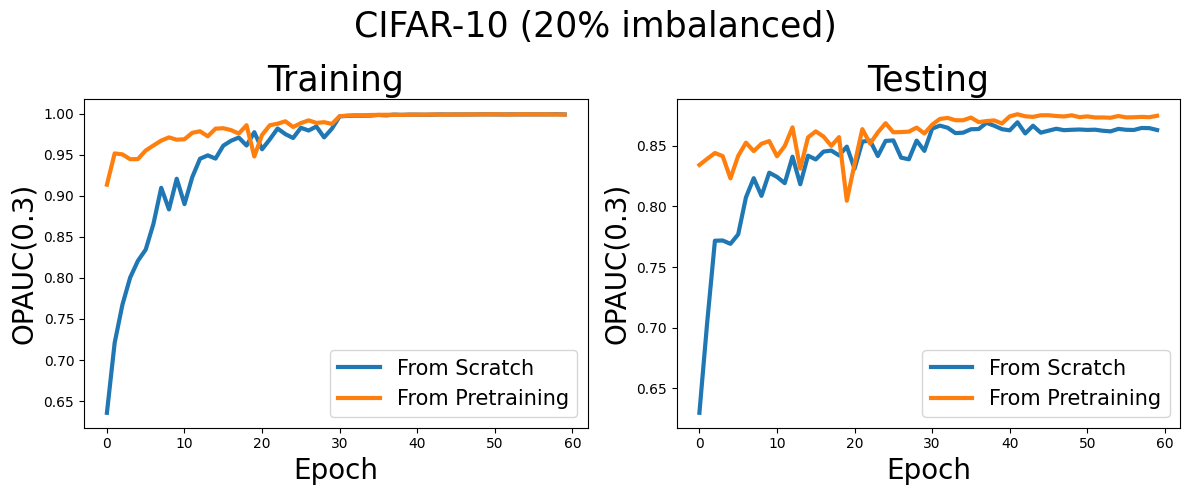

In [1]:
import matplotlib.pyplot as plt
import numpy as np


tr_pAUC= [0.9136682184609737, 0.9517632978422141, 0.9506051189223815, 0.9446549060621192, 0.9448721741895119, 0.9553083587887938, 0.9614520149623798, 0.9673729312719279, 0.9712668124473427, 0.9684614213627522, 0.969031741760386, 0.9768724826395, 0.9787389748857618, 0.972618762105704, 0.9819383784116936, 0.9824749153089939, 0.9801847539971296, 0.9759544325932434, 0.9861215766419662, 0.94802891637734, 0.9742945431398482, 0.9860951032311058, 0.9879519023728125, 0.9909198847148448, 0.9839547896495817, 0.9886518771869768, 0.9920652092915674, 0.9889322806164584, 0.9898229531439064, 0.9876859668679878, 0.9970812494750148, 0.9978576703833218, 0.9982887449720146, 0.9983248235880461, 0.9985837497448606, 0.9987383051150596, 0.9988528329894066, 0.9987962399128876, 0.9987518635950197, 0.998998087663014, 0.9990350738401836, 0.9989643098133549, 0.999234712490438, 0.9989916964360283, 0.9990960559212947, 0.9991606569456097, 0.999160259514824, 0.9992489302157771, 0.9993013370841397, 0.9992642981673392, 0.9994508690045507, 0.9992692635407481, 0.9990622670842126, 0.9994277263524861, 0.9994164206081635, 0.9993182658776183, 0.9993755668581037, 0.999262087183909, 0.9992265686125232, 0.9990694836236276]
te_pAUC = [0.8341716078431373, 0.8391899607843137, 0.8440392156862745, 0.8414500392156863, 0.823107137254902, 0.8416680784313725, 0.8525552941176469, 0.8455767843137254, 0.8516702745098039, 0.8538396862745098, 0.8413189019607843, 0.84976, 0.8651912156862744, 0.8311450980392157, 0.8569256470588236, 0.8618810980392155, 0.8575761568627451, 0.8499369411764706, 0.8571290980392157, 0.8046785882352943, 0.8349985882352942, 0.8637057254901961, 0.8517753725490196, 0.8610061176470587, 0.8685794509803921, 0.8611127843137256, 0.8612837647058823, 0.8616470588235294, 0.8649800784313726, 0.8601126274509804, 0.8673957647058823, 0.8721054117647059, 0.8729427450980392, 0.8710494117647058, 0.871019294117647, 0.873260862745098, 0.8694773333333333, 0.8703607843137255, 0.8709029019607842, 0.8683535686274511, 0.8742487843137254, 0.8759701960784314, 0.8742820392156863, 0.8738189803921568, 0.8751306666666666, 0.8751614117647059, 0.8745226666666668, 0.8741687843137256, 0.875124862745098, 0.8735847843137254, 0.8742079999999999, 0.8733223529411764, 0.8733339607843138, 0.873078588235294, 0.8745618823529412, 0.8733992156862744, 0.8734832941176471, 0.8738170980392157, 0.8735460392156862, 0.8747134117647057]
tr_pAUC_scratch = [0.6356903545832213, 0.7210205775802815, 0.767468625535477, 0.8005981139567835, 0.8209403917942953, 0.8345637945534954, 0.866052684924753, 0.9098821439963045, 0.8835058544209279, 0.9209312117584438, 0.8899414743626047, 0.9227558077051679, 0.9452859542605039, 0.9493837033022419, 0.9454534120045476, 0.9611925315862568, 0.9671769438992941, 0.9710854728791765, 0.9614036021792345, 0.9776061414393387, 0.9568010818218176, 0.9689421085611798, 0.982109825532059, 0.9753092539410508, 0.9705543687916516, 0.9829754175399547, 0.9796734335495003, 0.9845552466648984, 0.9712936892535897, 0.9818976169559868, 0.9968739993659712, 0.9974880619502038, 0.9977731378597904, 0.9977342995170321, 0.9978620468308591, 0.9986271378225131, 0.9980927098825727, 0.9990495706460671, 0.9987034002697288, 0.999049182946999, 0.9989652575570687, 0.9989112537452571, 0.9990108289926309, 0.9992897108209923, 0.9991501498299746, 0.9992343982501406, 0.9992116979203324, 0.9992235294913262, 0.9993363505479946, 0.999393357065544, 0.9992819075531902, 0.999232876962947, 0.9993267506795718, 0.999304969840104, 0.9992699284368018, 0.9993589300161501, 0.9992910836210124, 0.9993503431881259, 0.9994803711770379, 0.999233425392317]
te_pAUC_scratch = [0.6298767058823529, 0.704208, 0.7717273725490196, 0.7719074509803923, 0.769153568627451, 0.7769876078431373, 0.8074996078431373, 0.8232696470588234, 0.8086773333333332, 0.8277976470588235, 0.8243394509803922, 0.8191604705882353, 0.8410145882352941, 0.8182732549019607, 0.841843137254902, 0.8387259607843137, 0.8451968627450981, 0.8460429803921569, 0.8420614901960783, 0.8492727843137255, 0.8310625882352942, 0.8534343529411765, 0.8542500392156863, 0.841534431372549, 0.8540028235294117, 0.8544090980392156, 0.8401998431372548, 0.8388323137254903, 0.8542553725490196, 0.8457979607843136, 0.8640969411764705, 0.8666164705882353, 0.8648514509803922, 0.8604235294117646, 0.8607930980392158, 0.8636122352941176, 0.8637712941176471, 0.8689094901960784, 0.8665320784313726, 0.8636730980392155, 0.8627203137254902, 0.8693690980392157, 0.8601540392156861, 0.8665207843137255, 0.8607909019607842, 0.862432, 0.8640138039215686, 0.8628445490196077, 0.8631764705882352, 0.8634083137254902, 0.8630629019607843, 0.8632549019607842, 0.8623711372549019, 0.8618704313725489, 0.8638996078431372, 0.8631716078431373, 0.8630183529411763, 0.864654431372549, 0.8645311372549019, 0.862983843137255]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12,5))
plt.suptitle('CIFAR-10 (20% imbalanced)',fontsize=25)

x=np.arange(len(tr_pAUC))
ax0.plot(x, tr_pAUC_scratch,  label='From Scratch', linewidth=3)
ax0.plot(x, tr_pAUC,  label='From Pretraining', linewidth=3)
ax0.set_title('Training',fontsize=25)
ax1.plot(x, te_pAUC_scratch, label='From Scratch', linewidth=3)
ax1.plot(x, te_pAUC, label='From Pretraining', linewidth=3)
ax1.set_title('Testing',fontsize=25)

ax0.legend(fontsize=15)
ax1.legend(fontsize=15)
ax0.set_ylabel('OPAUC(0.3)', fontsize=20)
ax0.set_xlabel('Epoch', fontsize=20)
ax1.set_ylabel('OPAUC(0.3)', fontsize=20)
ax1.set_xlabel('Epoch', fontsize=20)

plt.tight_layout()
plt.savefig('sopa_p.png')